# How Models Pack Concepts into Manifolds
## looking at the theory, breaking the perfect world, and hunting for little circles

### **A surprising inner world**

In one approximation, we can say that AI models process inputs layer by layer. At each layer, the model outputs a vector $h \in \mathbb{R}^D$. For a single example, this vector is naturally read as a point — where a specific object landed in activation space. The averaged vector of a group of similar examples is naturally read as a centroid — a prototype of the group (also a point). The contrast between some groups, or between a group and a reference point, is naturally called a **direction** (now a vector). The group itself is naturally read as a **region** (now a chunk of space).

> All these points, centroids, regions, and directions look like black boxes. Abstractions, if you like. But the moment we give them structure — we see a ton of beauty. For example, we can geometrically understand and find **concepts** packed into **manifolds**.

**What is a concept, and what is a manifold? What structures form cyclic components, and how do we dig them out of a model? Why does the theory exist and get found empirically, but doesn't scale yet? These are the questions this article tries to answer.**
______

> Hi! My name (still, if you've read my tutorials before) is Sabrina — nice to meet you if this is your first time. I'm an XAI/MI researcher, and I love taking things from the field apart in the form of articles, blog posts and even (though rarely) memes. Welcome to the read =)

### **How we try to understand spaces**

In the intro paragraph, we saw examples of how we can describe, in human language, the representations inside a model.

- Based on data samples (and call them **points**);
- Based on the difference between polar groups (and call it a **direction**);
- Based on the place and shape occupied by a group of similar objects (and call it a **region**)

Everything we did in the examples above was to give an abstract space an interpretation that's understandable to us. Any such meaningful interpretation is called a **concept** in the interpretability literature. So let's fix the terminology for this post:

> a concept is an entity that has a name in natural language and is packed into something mathematical. This is a rough, ugly, completely formula-free definition — but it'll help us going forward.

I also have to note here that the notion of a concept is inconsistent across the XAI literature. It's a direction, a structure, and something with cognitive-science roots — all at once. But we have the terminology of this tutorial in our hands, and we'll go with it.

What we're doing when we **train** models is, to some extent, packing concepts into a space of some dimensionality — because real-world objects, in terms of our fixed definition, are concepts, as far as models are concerned. And we see that they get packed in like a bottomless backpack — very unexpectedly, and very well.

Is there, even hypothetically, any theoretical description of this? There is.

## **Concepts as structures**

Empirically, the following ideas are known: polar scales — "warm–cold", "rude–tolerant" — turn out to be a **direction**
$\mathbb{R}^1$ ([Tigges et al., 2023](https://arxiv.org/abs/2310.15154));
the closed cycle of weekdays — a **circle** $S^1$ ([Engels et al., 2024](https://arxiv.org/abs/2405.14860));
categories and hierarchies — **vertices of polytopes**: categories form simplices (or rather, their vertices), and nested hierarchies form product-polytopes of these
([Park et al., 2024](https://arxiv.org/abs/2406.01506)).

>  A simplex is a polytope in n-dimensional space. For example, a 0-dimensional simplex is a point, a 1-dimensional one is a segment, a 2-dimensional one is a triangle, a 3-dimensional one is a tetrahedron, and so on. A polytope is a union of finitely many simplices.

The shapes described above are built differently from each other. Two of them are manifolds, and for those we can define an intrinsic dimension — the number of independent, continuous degrees of freedom in the concept's value.

> This is a genuinely important thing to wrap your head around, especially if you don't work with $D, d, x, \propto, \forall$ and so on daily. As a characteristic, $d$ is about *structure*. It tells you how many dimensions you need to describe and traverse all of the concept's states inside the model's space. But it is not about the number of unique values, or the number of coordinates needed to describe an object in $R^n$. We'll see examples below. The links between `concept — structure — d` are something we don't know as of 2026 — but, again, we're discovering them.

For the concepts described above, the following dimensions hold:

| Concept | Shape | $d$ |
|---|---|---|
| Any binary concept | two isolated points | $0$ |
| Weekday, hour, month | one cyclic parameter — moving from one value to the next | $1$ |
| Taxonomy, hierarchy | a tree | not applicable |

**Why these values of $d$**

- $d = 0$: formally this is a single point, and a 0-dimensional manifold is a discrete set of points: the neighborhood of each point is just itself. To specify the value of a binary concept, you don't need a single number — you just pick one of two points.

- $d = 1$: to specify a weekday as a point on a cycle, one number is enough — an angle. Locally, the arc is indistinguishable from a piece of a straight line; globally it's closed: after 7 steps, you're back where you started.

- Not applicable.
    - No continuous parameter. For a simplex, only the vertices carry any meaning. There's nowhere to move *inside* the concept, and we're back to the $d=0$ case.

    - No homogeneity. A manifold requires the neighborhood of every point to look the same — and this one doesn't.

So read our "not applicable" as "the question isn't even asked in this language." Simplices and polytopes have different characteristics instead: the number of vertices $k$, the angles between them, and how simplices of neighboring levels combine into a product.

Back to the backpack example. However bottomless it looks, it is, generally speaking, $X$ liters. Likewise, a model has $D$ dimensions — and every concept has a size $d$.

At what cost each such shape can be packed in without self-intersections (i.e. flatly, roughly speaking) — how many dimensions it needs — was theoretically described by Hassler Whitney in the theorem that bears his name. Let's see how it goes.

**Whitney's Theorem (1944).** Any smooth $d$-dimensional manifold $M$ can be smoothly embedded into $\mathbb{R}^{2d}$.

*(This is the "strong" version — proved in 1944. There's also a weak version — embedding into $\mathbb{R}^{2d+1}$ — which Whitney proved in 1936)*

Let's fix the answers to some possible questions:

- **What is a manifold, and why are we specifically interested in them?**

    - *Formally.* $M$ is a smooth $d$-dimensional manifold if every point has a neighborhood that can be identified, bijectively and smoothly, with an open piece of $\mathbb{R}^d$ (this identification is called a **chart**, and a set of charts is an **atlas**). The number $d$ is exactly the intrinsic dimension: how many local coordinates you need to specify a point.

    - *Intuitively.* A manifold of dimension $d$ is a space that **looks like $\mathbb{R}^d$ near every point**, even if, as a whole, it's curved or closed. Globally the shape can be anything, but *locally* it's always a piece of $\mathbb{R}^d$. The classic mental-model example given when introducing manifolds is an ant on a circle: it's convinced it's crawling along a straight line. Or us, living on an almost-spherical Earth, locally convinced there's a flat plane around us. By the way, the Earth isn't a sphere. Because of its rotation around its own axis, it's flattened at the poles and slightly bulged at the equator. In geodesy and physics, the planet's real shape is called a geoid, and mathematically it's approximated as an ellipsoid of revolution.

    - *Why these specifically.* Lately, they're being found and reported in models more and more often. That's fairly natural — interpretability already leans on plenty of linear approximations as it is.

- **What does "smooth" mean, and what does "smoothly embed" mean?**

    - *Smooth* means **no kinks or corners**: transitions between charts are infinitely differentiable ($C^\infty$), so you can move along $M$ smoothly, and at every point there's a well-defined tangent direction (a velocity). This is what tells a circle apart from, say, the outline of a square with sharp corners.

    - To *embed* $f: M \to \mathbb{R}^{2d}$ smoothly means to place $M$ into the ambient space while satisfying three conditions:

      | Condition | Formally | What it forbids | What it gives you |
      |---|---|---|---|
      | smoothness | $f$ is infinitely differentiable | kinks, discontinuities | derivatives of every order are defined — there are tangents |
      | **immersion** | $df_p$ is injective at every point | collapsing directions, folds | the tangent space doesn't degenerate: different directions along $M$ map to different, nonzero directions |
      | **injectivity** | $f(p)=f(q)\Rightarrow p=q$ | self-intersections, gluing | the point $p$ can be uniquely recovered from its image $f(p)$ — nothing overlaps |

- **Can we get away with less?**

    Sometimes yes — but not always: it depends on the manifold.

    **Sometimes yes.** The sphere $S^n\hookrightarrow\mathbb{R}^{n+1}$ — and this is true by definition. An $n$-dimensional sphere is the set of points equidistant from the center:

    $S^n = \{x \in \mathbb{R}^{n+1} : x_1^2 + \dots + x_{n+1}^2 = r^2\}$

    An equation with $n+1$ coordinates carves out an $n$-dimensional surface — exactly one dimension less than the ambient space. So $S^n$ is **already given** as a subset of $\mathbb{R}^{n+1}$, and the inclusion $x \mapsto x$ itself serves as the embedding — nothing left to prove. Whitney would guarantee $\mathbb{R}^{2n}$, but the sphere only needs $\mathbb{R}^{n+1}$ — $n-1$ dimensions fewer.

    **Sometimes no.** The circle — the extreme case $S^1$ — cannot be placed onto the line $\mathbb{R}^1$, and here, on the contrary, $2d$ is exactly what's needed (people also say it's "tight" — meaning you have to use every bit of it).

    > This follows from a theorem with yet another pair of great names attached — the **Borsuk–Ulam theorem** (the case $n=1$):

    For any continuous $f: S^1 \to \mathbb{R}$, there exists a point $x \in S^1$ where $f(x) = f(-x)$.

    Here:
    - $f: S^1 \to \mathbb{R}$ — any continuous function from the circle to the line;
    - $-x$ — the antipodal point ($x$ and $-x$ are the opposite ends of a diameter);
    - $f(x) = f(-x)$ — the function takes the same value at two different points → **not injective** → not an embedding.

    *Sketch of the proof*: $g(x) = f(x) - f(-x)$ is antisymmetric ($g(-x) = -g(x)$), so it changes sign → by the intermediate value theorem $\exists\, x: g(x) = 0$, i.e. $f(x) = f(-x)$. Bottom line: any continuous $f: S^1 \to \mathbb{R}$ glues together at least two points → $S^1 \not\hookrightarrow \mathbb{R}^1$.

- **Does this actually hold up in practice?**

    No. Or rather — the theorem is true, it's proven. But it isn't a constraint on models, because this theorem is about a single manifold, not about packing many of them together. There are exponentially many almost-orthogonal directions available inside models — that's exactly what the superposition hypothesis rests on.

    On top of that, the theorem's conditions aren't cleanly satisfied in our setting either — Whitney requires smoothness and exact injectivity, whereas models think approximately.

    And there wouldn't be much to actually compute from it either way. All sorts of different structures coexist in a model at once, sharing the same 768 dimensions. To compute the capacity, you'd need a full list of concepts, and an analog of this argument for each one. We know neither.

    So what does Whitney actually give us, then? A hint about where to look: if what you're after is, say, a $d=1$ concept — go look for a plane.

But theory is nice to poke at. It sometimes helps you get organized, and besides — theory is beautiful. If you agree, here's a link — more theorems are nicely laid out in this lecture note, [here](http://staff.ustc.edu.cn/~wangzuoq/Courses/18F-Manifolds/Notes/Lec09.pdf).

Let's move on to the practical question — when do manifolds actually show up in models — and try to get our hands on one.

### **When do manifolds actually appear in models?**

A manifold shows up in a model's representations under three conditions:

1. **The concept is continuously ordered** — between values there's a notion of "close/far", "next", "greater/smaller"
2. **The model is forced to compute with this structure** — the training objective includes tasks that require operations on the concept
3. **There are enough contexts in the data** where the structure is clearly visible

We saw examples of this in the table above, and the anchor question for spotting a possible manifold is: does the model need to compute *between* values? If yes — there might be a manifold. If not — clusters.

> So the takeaway here is that being a manifold is always a property of the pair **(concept, task)**. The same "day of the week" can be $S^1$ in an autoregressive LLM, and just 7 clusters in a classifier with no temporal tasks.

**Is this useful? Yes!**

For example, ([Engels et al., 2024](https://arxiv.org/abs/2405.14860)) found circles via SAE clustering + PCA on the prompt task "Let's do some day of the week math. Two days from Monday is ___" in GPT-2 (layer 7) and Mistral 7B. We'll redo this finding below, on a slightly simpler setup. In their paper, they showed that intervening on the found structure changes the model's behavior.

A bigger example — [Shape Happens](https://arxiv.org/html/2510.01025v1). Their result — intervening on the found structure changes the model's behavior — is the same.

So manifolds aren't just an artifact — they're also something potentially used by the model. It's just not very scalable or well-understood yet. That wraps up the theory — hopefully you're motivated enough by now — let's go explore the model.

## **GPT-2: manifolds in a real model**

In [1]:
# ── Setup: all imports for the notebook live here ──────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import torch
from scipy.stats import kendalltau
from transformers import GPT2Model, GPT2Tokenizer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

from data import DAY_CONTEXTS as CTX, DAYS, NUMBERS, TEMPLATES, TEMPLATES_MATH  # local module

np.random.seed(42)
plt.rcParams.update({"font.size": 11, "figure.dpi": 100})
print("Ready.")

Ready.


Let's take GPT-2 small, everyone's favorite for simple experiments. Its parameters: 12 layers, 12 heads, $D_{\text{hidden}} = 768$, a vocabulary of 50,257 BPE tokens (byte-pair-encoded, meaning obtained iteratively so that frequent words tend to end up as whole tokens, while rare or complex words get split into smaller pieces).

As our concepts, let's take 3: ones known in the literature to be cyclic and to form a manifold.

| Concept | Tokens | Period | Intrinsic dim |
|---|---|---|---|
| Weekdays | Monday, …, Sunday | 7 | $d=1$ ($S^1$) |
| Months | January, …, December | 12 | $d=1$ ($S^1$) |
| Hours | one, …, twelve | 12 | $d=1$ ($S^1$) |

Let's check with our own hands how GPT-2 encodes these concepts.

**Whitney's theorem predicts the following:**

- Each $S^1$ is a circle and occupies its own 2D subspace $V_i \subset \mathbb{R}^{768}$

Let's look at reality below — and check with our own hands how GPT-2 actually encodes these concepts.

### **Setting up the problem**

**Metrics**
To measure how well everything lines up with the theory, let's also look at the following metrics:

- **$\tau_{\text{ang}}$ (angular tau) — is the cyclic *order* preserved.** We compute the angle of each point around the centroid, rank the points by angle, and compare against the ideal cycle $0,1,\dots,n{-}1$ using Kendall's rank correlation (taking the max over all shifts — a circle has no "start").

How to read it:
$\tau_{\text{ang}}=1$ — the points go around the circle in the right order (Mon→Tue→…→Sun→Mon); $\approx 0$ → the order is random. This checks the cycle's *structure*.

- **$R^2_{\text{circ}}$ — do the points lie on a *round* circle**. We fit a circle by least squares and measure how equidistant all the points are from the center.
  $=1$ — a perfect circle; lower — a lopsided circle.

In other words: $\tau_{\text{ang}}$ asks "is the *order* right?", $R^2_{\text{circ}}$ asks "is the *geometry* right?" — between the two, we've covered both sides.

**Where we'll measure**

We'll look both at static token embeddings $W_E$ and at hidden states.

- We'll look at the first to answer the question: "how did the tokens get packed into the model's space?" Recording hidden states isn't productive for this question, since we'd just be asking the model to continue generating from a single token. Since GPT-2 isn't explicitly trained on cyclic tasks, we have no particular reason to expect the right geometry or the right computational process to show up here.

- We'll look at the second to answer the question: "how is it useful for the model to appeal to these concepts?" This is where we'll need hidden states — they depend on the whole sentence.

So, that's the setup we've put together. Let's start analyzing — with the first one, naturally.

### **Setup on the embeddings**

In [2]:
# uv pip install transformers  (run once)

# Load model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

W_E = model.wte.weight.detach().numpy()  # (50257, 768) — token embeddings

D_MODEL = W_E.shape[1]  # 768
print(f"GPT-2 vocab: {W_E.shape[0]} tokens, D={D_MODEL}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 vocab: 50257 tokens, D=768


In [3]:
# Token concepts
CONCEPTS = {
    "Days": [
        " Monday",
        " Tuesday",
        " Wednesday",
        " Thursday",
        " Friday",
        " Saturday",
        " Sunday",
    ],
    "Months": [
        " January",
        " February",
        " March",
        " April",
        " May",
        " June",
        " July",
        " August",
        " September",
        " October",
        " November",
        " December",
    ],
    "Hours": [
        " one",
        " two",
        " three",
        " four",
        " five",
        " six",
        " seven",
        " eight",
        " nine",
        " ten",
        " eleven",
        " twelve",
    ],
}

SHORT = {
    "Days": ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    "Months": ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"],
    "Hours": ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"],
}

EMBS = {}  # name — (n, 768) token embeddings
PCAS = {}  # name — (n, 2) 2D projection
SUBS = {}  # name — (768, 3) PCA basis

# Get embeddings

for name, words in CONCEPTS.items():
    ids = [tokenizer.encode(w)[0] for w in words]  # get token IDs
    print(f"{name}: ids = {ids}")

    H = W_E[ids]
    EMBS[name] = H
    pca = PCA(n_components=3)
    PCAS[name] = pca.fit_transform(H)
    SUBS[name] = pca.components_.T  # (768, 3)

Days: ids = [3321, 3431, 3583, 3635, 3217, 3909, 3502]
Months: ids = [3269, 3945, 2805, 3035, 1737, 2795, 2901, 2932, 2693, 3267, 3389, 3426]
Hours: ids = [530, 734, 1115, 1440, 1936, 2237, 3598, 3624, 5193, 3478, 22216, 14104]


In [4]:
# Metrics: Concept Circularity


def angular_tau(H2, n):
    """τ_ang ∈ [0,1]: how well the CIRCULAR ORDER of points is preserved. 1 = perfect cycle."""
    # 1. Center of the point cloud (angles are measured relative to it)
    cx, cy = H2[:, 0].mean(), H2[:, 1].mean()
    # 2. Angle of each point relative to the center, in [-π, π]
    angles = np.arctan2(H2[:, 1] - cy, H2[:, 0] - cx)
    # 3. Rank each point by angle (which point comes 0th, 1st, ... around the circle).
    #    Double argsort: the first argsort gives sorted indices,
    #    the second converts them into ranks.
    ang_rank = np.argsort(np.argsort(angles))
    # 4. Compare the angular ordering with the IDEAL cycle 0,1,…,n−1,
    #    shifted by k. We try all shifts (a circle has no fixed starting point)
    #    and keep the best match.
    #    kendalltau measures rank correlation; abs() also captures
    #    the reverse traversal direction.
    best = max(abs(kendalltau(ang_rank, (np.arange(n) + k) % n).statistic) for k in range(n))
    return best


def fit_r2(pts):
    """R²_circ ∈ (−∞,1]: how well the points lie on a circle (equal distance from the center). 1 = perfect."""
    # The circle equation (x−cx)²+(y−cy)²=r² can be linearized as
    #   2·cx·x + 2·cy·y + (r²−cx²−cy²) = x²+y²
    #   →   M·p = b, where p=(cx, cy, r²−cx²−cy²)

    # 1. Build the linear system
    M = np.column_stack([2 * pts[:, 0], 2 * pts[:, 1], np.ones(len(pts))])
    b = pts[:, 0] ** 2 + pts[:, 1] ** 2

    # 2. Least-squares solution → fitted circle center and radius
    p, _, _, _ = np.linalg.lstsq(M, b, rcond=None)
    cx, cy = p[0], p[1]
    r = np.sqrt(abs(p[2] + cx**2 + cy**2))  # recover r from p[2]=r²−cx²−cy²

    # 3. Distance of each point to the fitted center
    d = np.sqrt((pts[:, 0] - cx) ** 2 + (pts[:, 1] - cy) ** 2)

    # 4. R²: 1 − (variance of d around radius r) / (total variance of d).
    #    If all points are equally distant from the center (d≈r),
    #    then ss_res≈0 and R²≈1.
    ss_res = np.sum((d - r) ** 2)  # deviation from the fitted circle
    ss_tot = np.sum((d - d.mean()) ** 2)  # total radius variance
    return float(1 - ss_res / (ss_tot + 1e-12))


print(f'{"Concept":12s} {"var@2PC":>8s} {"var@3PC":>8s} {"angular_tau":>12s}  {"R²_circ":>8s}')

for name, H2 in PCAS.items():
    H = EMBS[name]
    pca = PCA(3).fit(H)
    pca_v2 = pca.explained_variance_ratio_[:2].sum()
    pca_v3 = pca.explained_variance_ratio_[:3].sum()
    tau = angular_tau(H2, H2.shape[0])
    r2 = fit_r2(H2)
    print(f"{name:12s} {pca_v2:8.1%}  {pca_v3:8.1%}  {tau:12.3f}  {r2:8.3f}")

Concept       var@2PC  var@3PC  angular_tau   R²_circ
Days            61.6%     75.4%         1.000    -0.004
Months          38.6%     50.7%         1.000    -0.024
Hours           54.6%     65.1%         0.939    -0.005


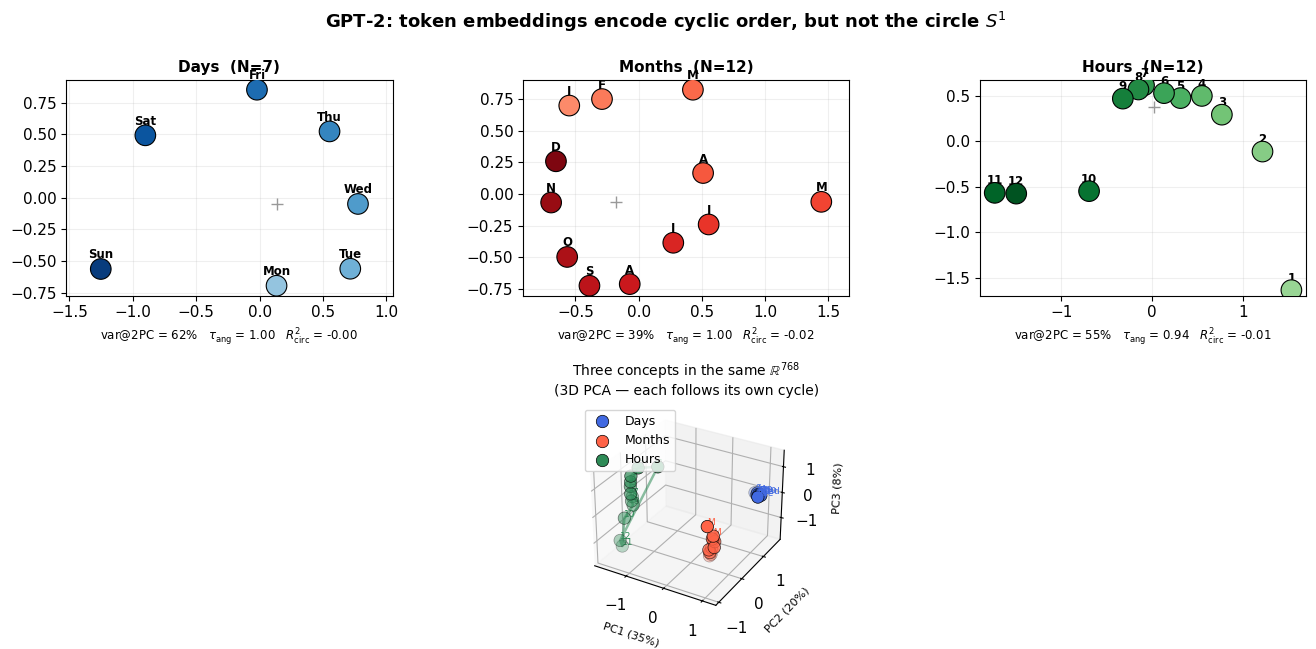

In [5]:
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.4)

concept_names = list(CONCEPTS.keys())
colors_map = {"Days": plt.cm.Blues, "Months": plt.cm.Reds, "Hours": plt.cm.Greens}

#  Row 1: 3 concept circles
for ci, name in enumerate(concept_names):

    ax = fig.add_subplot(gs[0, ci])
    H2 = PCAS[name]
    n = H2.shape[0]
    lbs = SHORT[name]
    clr = colors_map[name](np.linspace(0.4, 0.95, n))

    # Points
    # Here you can play with component pairs (0, 1), (0, 2), (2, 1)
    ax.scatter(H2[:, 0], H2[:, 1], c=clr, s=220, zorder=5, ec="k", lw=0.8)
    for i, lb in enumerate(lbs):
        ax.text(
            H2[i, 0],
            H2[i, 1] + 0.06,
            lb,
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold",
        )

    # Annotation: angular tau
    tau = angular_tau(H2, n)
    r2 = fit_r2(H2)
    H = EMBS[name]
    pca_v = PCA(2).fit(H).explained_variance_ratio_[:2].sum()
    ax.set_title(f"{name}  (N={n})", fontsize=11, fontweight="bold")
    ax.set_xlabel(
        f"var@2PC = {pca_v:.0%}   $\\tau_{{\\rm ang}}$ = {tau:.2f}   $R^2_{{\\rm circ}}$ = {r2:.2f}",
        fontsize=8.5,
    )
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(alpha=0.2)

    # Shade to show cyclic direction
    cx, cy = np.median(H2[:, 0]), np.median(H2[:, 1])
    ax.plot(cx, cy, "k+", ms=8, lw=1.5, alpha=0.4)

#  Row 2 mid: all 3 concepts in 3D PCA
ax6 = fig.add_subplot(gs[1, 0:3], projection="3d")
H_all = np.vstack([EMBS[n] for n in concept_names])
pca3 = PCA(3)
H3_all = pca3.fit_transform(H_all)
counts = [EMBS[n].shape[0] for n in concept_names]
offsets = np.cumsum([0] + counts[:-1])

clr3 = ["royalblue", "tomato", "seagreen"]
for i, (name, off, cnt) in enumerate(zip(concept_names, offsets, counts)):
    H3 = H3_all[off : off + cnt]
    loop = list(range(cnt)) + [0]
    ax6.plot(H3[loop, 0], H3[loop, 1], H3[loop, 2], "-", color=clr3[i], lw=1.8, alpha=0.55)
    ax6.scatter(
        H3[:, 0], H3[:, 1], H3[:, 2], color=clr3[i], s=80, zorder=5, ec="k", lw=0.5, label=name
    )
    for j, lb in enumerate(SHORT[name]):
        ax6.text(H3[j, 0], H3[j, 1], H3[j, 2] + 0.05, lb, fontsize=6.5, color=clr3[i])

ev3 = pca3.explained_variance_ratio_
ax6.set_xlabel(f"PC1 ({ev3[0]:.0%})", fontsize=8)
ax6.set_ylabel(f"PC2 ({ev3[1]:.0%})", fontsize=8)
ax6.set_zlabel(f"PC3 ({ev3[2]:.0%})", fontsize=8)
ax6.set_title(
    "Three concepts in the same $\\mathbb{R}^{768}$\n" "(3D PCA — each follows its own cycle)",
    fontsize=10,
)
ax6.legend(fontsize=9, loc="upper left")


fig.subplots_adjust(hspace=0.1, wspace=0.0)
plt.suptitle(
    "GPT-2: token embeddings encode cyclic order, but not the circle $S^1$",
    fontsize=13,
    fontweight="bold",
)
plt.show()

What we see:

- **The order is perfect.** $\tau_{\text{ang}}=1.0$ for days and months, $0.94$ for hours: the points go
  around the circle in exactly calendar order.

- **The circle is "lopsided."** $R^2_{\text{circ}}\approx 0$ (and even slightly negative) — the points form
  a loop, but they don't lie **anywhere near a round circle**. So — yes, the model stores **cyclic order**, but no — its geometry isn't round.

- They sit in different regions of the space.

## Will context help us?

> A technical gotcha for your future self.
    When the text starts right with the word you're interested in, you're in for an unpleasant surprise. Without a BOS token, GPT-2 produces an anomalously large activation norm on the very first token of the sequence — this is a transformer artifact: the first token has nothing to its left for attention to "look at," and the model compensates for that in a non-standard way. The fix is simple — add a BOS token before encoding.

Let's look at a few different examples and analyze the hidden states at the position of the day token (day, because it's the best candidate; token position, as the method — to retrace the steps of [Not All Language Model Features Are One-Dimensionally Linear](https://arxiv.org/pdf/2405.14860), since it's foundational in the world of representation-geometry research). We could also take last-token hidden states — the result there might come out cleaner, but I'm deliberately using the day token instead. Why — at the end of the article [footnote 1].

For ease of analysis, and to keep things comparable with a case where we only have 7 points, we'll analyze per-day centroids using the same metrics as above. We'll also additionally check whether the days are linearly separable from each other, using logistic regression. We'll need this later too, to see how strongly the model separates days from one another in a linear sense.

In [6]:
# ── Day cycle ACROSS ALL LAYERS: where cyclic order emerges ──────────

N_L = model.config.n_layer + 1  # 13: embeddings + 12 transformer blocks


def day_token_pos(ids, day):
    """Position of the last subtoken of the word `day` in `ids`.
    Tries both ' day' and 'day' (sentence-initial case)."""

    for prefix in (" ", ""):
        sub = tokenizer.encode(prefix + day)
        for i in range(len(ids) - len(sub) + 1):
            if ids[i : i + len(sub)] == sub:
                return i + len(sub) - 1

    return None


reps = [[[] for _ in range(7)] for _ in range(N_L)]
used, skipped = 0, 0

with torch.no_grad():
    for di, day in enumerate(DAYS):
        for c in CTX:
            # BOS prefix: without it, GPT-2 produces an anomalously large
            # activation norm on the very first token of the sequence — some
            # templates in data.py start directly with "{day}", and without
            # this prefix the day token would land exactly at position 0
            # (verified: norm drops from ~3000 to ~90 once the prefix is added).
            ids = [tokenizer.eos_token_id] + tokenizer.encode(c.format(day=day))
            pos = day_token_pos(ids, day)

            if pos is None:
                skipped += 1
                continue

            used += 1
            hs = model(torch.tensor([ids]), output_hidden_states=True).hidden_states
            for L in range(N_L):
                reps[L][di].append(hs[L][0, pos].numpy())

print(f"examples used: {used}, skipped: {skipped}")
print("samples per day:", [len(reps[0][d]) for d in range(7)])

examples used: 504, skipped: 0
samples per day: [72, 72, 72, 72, 72, 72, 72]


In [7]:
#  Layer sweep: what changes with depth
# reps[L][day] contains non-averaged contextual representations
# from the extraction cell above

taus, circle_r2s = [], []

for L in range(N_L):
    # One centroid per day
    centroids = np.array([np.mean(reps[L][d], axis=0) for d in range(7)])

    # Project the seven day centroids into 2D
    centroids_2d = PCA(n_components=2).fit_transform(centroids)

    # How well the cyclic order of weekdays is preserved
    taus.append(angular_tau(centroids_2d, n=7))

    # How closely the projected centroids lie on a circle
    circle_r2s.append(fit_r2(centroids_2d))


print("Angular tau:", [round(x, 3) for x in taus])
print("Circle R²:  ", [round(x, 3) for x in circle_r2s])

Angular tau: [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.81)]
Circle R²:   [-0.004, -0.003, -0.001, -0.002, -0.001, -0.002, -0.001, -0.002, -0.002, -0.002, -0.002, -0.002, -0.03]


In [8]:
def estimate_random_tau_baseline(n=7, n_trials=10_000, seed=42):
    rng = np.random.default_rng(seed)
    ideal = np.arange(n)
    values = []

    for _ in range(n_trials):
        random_rank = rng.permutation(n)

        best = max(
            abs(kendalltau(random_rank, (ideal + shift) % n).statistic) for shift in range(n)
        )
        values.append(best)

    values = np.asarray(values)

    return {
        "mean": values.mean(),
        "median": np.median(values),
        "q95": np.quantile(values, 0.95),
    }


tau_null = estimate_random_tau_baseline()
print(tau_null)

{'mean': np.float64(0.5614476190476191), 'median': np.float64(0.5238095238095238), 'q95': np.float64(0.8095238095238096)}


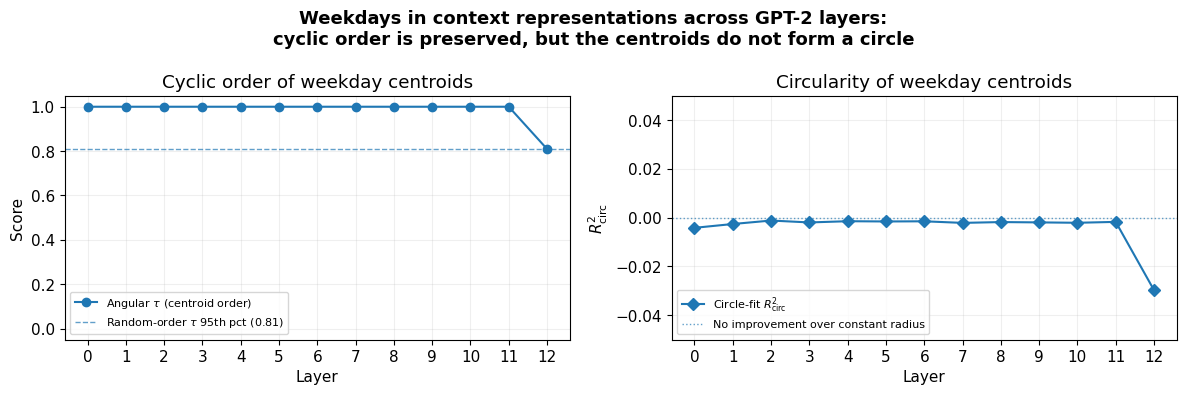

In [9]:
layers = np.arange(N_L)

# Convert NumPy scalar objects to ordinary floats for cleaner handling
taus_plot = np.asarray(taus, dtype=float)
circle_r2s_plot = np.asarray(circle_r2s, dtype=float)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))

# ── Left panel: cyclic order and linear decodability ─────────────────
axL.plot(layers, taus_plot, "o-", label=r"Angular $\tau$ (centroid order)")
axL.axhline(
    tau_null["q95"],
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label=rf'Random-order $\tau$ 95th pct ({tau_null["q95"]:.2f})',
)

axL.set_ylim(-0.05, 1.05)
axL.set_xlabel("Layer")
axL.set_ylabel("Score")
axL.set_title("Cyclic order of weekday centroids")
axL.set_xticks(layers)
axL.grid(alpha=0.2)
axL.legend(fontsize=8, loc="lower left")


# ── Right panel: circularity of the seven centroids ──────────────────
axR.plot(layers, circle_r2s_plot, "D-", label=r"Circle-fit $R^2_{\mathrm{circ}}$")

axR.axhline(
    0.0, linestyle=":", linewidth=1, alpha=0.7, label="No improvement over constant radius"
)

# A narrow range makes the small deviations around zero visible
r2_margin = 0.01
r2_min = min(-0.05, circle_r2s_plot.min() - r2_margin)
r2_max = max(0.05, circle_r2s_plot.max() + r2_margin)
axR.set_ylim(r2_min, r2_max)

axR.set_xlabel("Layer")
axR.set_ylabel(r"$R^2_{\mathrm{circ}}$")
axR.set_title("Circularity of weekday centroids")
axR.set_xticks(layers)
axR.grid(alpha=0.2)
axR.legend(fontsize=8, loc="lower left")


fig.suptitle(
    "Weekdays in context representations across GPT-2 layers:\n"
    "cyclic order is preserved, but the centroids do not form a circle",
    fontsize=13,
    fontweight="bold",
)

fig.tight_layout()
plt.show()

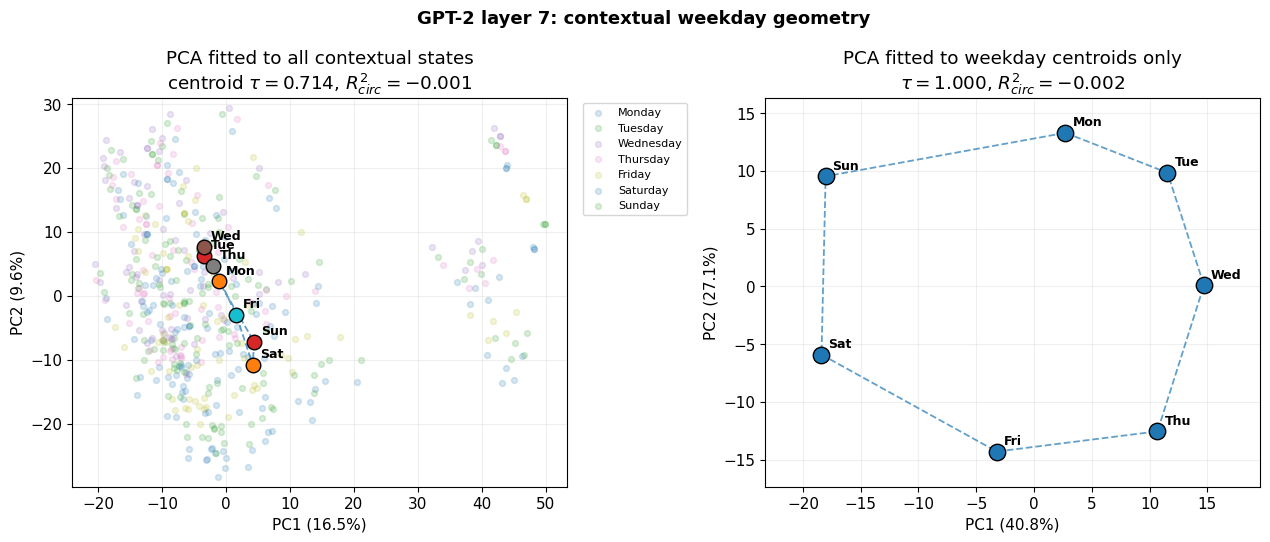

In [10]:
# ── Contextual weekday PCA: all points vs. weekday centroids ─────────
L = 7  # selected GPT-2 layer

# All contextual representations at layer L
X = np.vstack([np.asarray(reps[L][d]) for d in range(7)])

y = np.concatenate([np.full(len(reps[L][d]), d) for d in range(7)])

# Weekday centroids in the original hidden-state space
centroids = np.array([X[y == d].mean(axis=0) for d in range(7)])

loop = np.r_[np.arange(7), 0]

fig, (ax_all, ax_cent) = plt.subplots(1, 2, figsize=(13, 5.5))


# ── Left: PCA fitted to all contextual representations ──────────────
pca_all = PCA(n_components=2)
X_2d = pca_all.fit_transform(X)

# Centroids expressed in the same PCA coordinate system
centroids_all_2d = np.array([X_2d[y == d].mean(axis=0) for d in range(7)])

for d, day in enumerate(DAYS):
    mask = y == d

    ax_all.scatter(X_2d[mask, 0], X_2d[mask, 1], s=18, alpha=0.18, label=day)

    ax_all.scatter(
        centroids_all_2d[d, 0],
        centroids_all_2d[d, 1],
        s=110,
        edgecolor="black",
        linewidth=1.0,
        zorder=4,
    )

    ax_all.annotate(
        day[:3],
        centroids_all_2d[d],
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

ax_all.plot(
    centroids_all_2d[loop, 0], centroids_all_2d[loop, 1], "--", linewidth=1.3, alpha=0.7
)

tau_all = angular_tau(centroids_all_2d, n=7)
r2_all = fit_r2(centroids_all_2d)
ev_all = pca_all.explained_variance_ratio_

ax_all.set_xlabel(f"PC1 ({ev_all[0]:.1%})")
ax_all.set_ylabel(f"PC2 ({ev_all[1]:.1%})")
ax_all.set_title(
    "PCA fitted to all contextual states\n"
    rf"centroid $\tau={tau_all:.3f}$, "
    rf"$R^2_{{circ}}={r2_all:.3f}$"
)
ax_all.set_aspect("equal", adjustable="datalim")
ax_all.grid(alpha=0.2)
ax_all.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")


# ── Right: PCA fitted only to the seven weekday centroids ───────────
pca_cent = PCA(n_components=2)
centroids_2d = pca_cent.fit_transform(centroids)

ax_cent.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1], s=140, edgecolor="black", linewidth=1.0, zorder=4
)

ax_cent.plot(centroids_2d[loop, 0], centroids_2d[loop, 1], "--", linewidth=1.3, alpha=0.7)

for d, day in enumerate(DAYS):
    ax_cent.annotate(
        day[:3],
        centroids_2d[d],
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
    )

tau_cent = angular_tau(centroids_2d, n=7)
r2_cent = fit_r2(centroids_2d)
ev_cent = pca_cent.explained_variance_ratio_

ax_cent.set_xlabel(f"PC1 ({ev_cent[0]:.1%})")
ax_cent.set_ylabel(f"PC2 ({ev_cent[1]:.1%})")
ax_cent.set_title(
    "PCA fitted to weekday centroids only\n"
    rf"$\tau={tau_cent:.3f}$, "
    rf"$R^2_{{circ}}={r2_cent:.3f}$"
)
ax_cent.set_aspect("equal", adjustable="datalim")
ax_cent.grid(alpha=0.2)


fig.suptitle(f"GPT-2 layer {L}: contextual weekday geometry", fontsize=13, fontweight="bold")

fig.tight_layout()
plt.show()

By the metrics, it's still the same story — cyclic and lopsided — and if we look at the projections, they no longer show a circle. But that's not really a problem. The result follows directly from how it's constructed. If (when) we fit PCA on contextual points, by definition we shouldn't expect to get a cycle out of it. PCA looks for the direction of maximum variance, and for contextual points, that variance is:

$$\text{total variation} =
\text{weekday variation} + \text{context variation}
+\text{position variation}
+ \text{interaction effects}$$

That's a lot of components. So, once again — PCA doesn't look for cycles. It picks directions that explain the largest share of total variance — the top principal components have no obligation to show the calendar cycle, especially if (when) the variance from context is bigger than the differences between weekdays. And we have a lot of different contexts. We asked for it, we got it.

But a bad doctor is one who won't tell you how to treat the problem — to tell context noise apart from the structure of the days themselves, we can look at two projections:

* PCA fit on all the contextualized representations;
* PCA fit only on the seven weekday centroids.

As you can see — the second one brings back the cyclic result.

## The day-math experiment

A cyclic concept surfaces in tasks like "two days after Monday is Wednesday," and on a circle, a step like that is a **rotation**: adding $k$ days = rotating the point by an angle of $2\pi k/7$. Rotation is a cheap linear operation, the same for any shift, and an attention head can implement it easily. And this computation happens during the forward pass on a specific sentence — that is, in contextual activations, not in the static dictionary $W_E$.

Let's look at the representations of days and numerical shifts. We need the numerical shifts here so that we get both a computation task and a control condition at the same time. So the main experiment splits into two:

- Experiment A: day and number, but without a computation task.
The model sees both values, but the context doesn't require it to interpret the number as a shift along the weekday cycle.
- Experiment B: the calendar-shift task — the same day and number, but with the task of "counting forward by days." For example:
"Two days from Monday is …"

If the cyclic geometry is specifically tied to carrying out the calendar operation, it should be more pronounced in the day-math regime than in the control sentences.

Let's check this by comparing:

* the ordering of representations by day;
* the quality of the circular fit;
* the PCA structure, both for all the points and for the group centroids.

In short, all the same things as above, but on top of the general-setup metrics and projections, we also use a projection onto the plane defined by the centroids of one of the classes (days or numbers). Specifically, for the chosen variable, we first compute the class centroids:

For the chosen variable (say, weekdays or numbers), we first compute the class centroids:

$$\mathbf{c}_k= \frac{1}{N_k} \sum_{i:\,y_i=k}\mathbf{x}_i,$$

then build a two-dimensional PCA subspace from these centroids, i.e. of size $\mathbb{R}^{n_centroids\times2}$. Denoting this matrix as $\mathbf{B}\in\mathbb{R}^{n_centroids\times2}$, and $\bar{\mathbf c} = \frac1K\sum_{k=1}^{K}\mathbf c_k$ as the mean center of the centroids, every hidden representation is then projected onto the found plane using the formula:

$$\mathbf z_i = (\mathbf x_i-\bar{\mathbf c})\mathbf B$$

Unlike plain PCA, this projection specifically picks out the directions defined by the differences between classes, and then all hidden representations get mapped into this subspace. This lets us separately analyze the geometry tied, in our case, to weekdays and to numbers.

> We're about to get something pretty any moment now, but:
The main limitation is that we don't have very many templates. My goal for this tutorial was never to produce an exact benchmark of this model (explanation below — why) [footnote 2]. The goal of this tutorial is to give examples and a direction.

In [11]:
# ── Experiment A: joint (day, number), WITHOUT the arithmetic task ──
LAYER = 7


rows, dlab, hlab = [], [], []

with torch.no_grad():
    for di, day in enumerate(DAYS):
        d_id = tokenizer.encode(" " + day)[0]

        for hi, number in enumerate(NUMBERS):
            h_id = tokenizer.encode(" " + number)[0]

            for tmpl in TEMPLATES:
                text = tmpl.format(day=day, number=number)
                ids = [tokenizer.eos_token_id] + tokenizer.encode(
                    text
                )  # BOS prefix — see note above

                if d_id not in ids or h_id not in ids:
                    continue

                input_ids = torch.tensor([ids])
                hidden_states = model(input_ids, output_hidden_states=True).hidden_states[
                    LAYER
                ][0]

                day_state = hidden_states[ids.index(d_id)]
                hour_state = hidden_states[ids.index(h_id)]

                rows.append((day_state + hour_state).cpu().numpy())
                dlab.append(di)
                hlab.append(hi)

H = np.array(rows)
days = np.array(dlab)
numbers = np.array(hlab)

print(f"H: {H.shape} ")

H: (840, 768) 


In [12]:
#  Experiment A: global contextual PCA vs. centroid-defined planes
N_DAY = len(np.unique(days))
N_NUMBERS = len(np.unique(numbers))


def projected_centroids(X_2d, labels, n_classes):
    """Compute class centroids in a two-dimensional projection."""
    return np.array([X_2d[labels == i].mean(axis=0) for i in range(n_classes)])


def centroid_plane(X, labels, n_classes):
    """
    Fit a two-dimensional PCA plane to class centroids in the original
    representation space and project all contextual points onto that plane.
    """
    centroids = np.array([X[labels == i].mean(axis=0) for i in range(n_classes)])
    center = centroids.mean(axis=0)
    pca = PCA(n_components=2)
    pca.fit(centroids - center)
    basis = pca.components_.T
    projection = (X - center) @ basis
    return projection, basis, center, pca


def add_cycle(ax, centroids_2d, labels=None, line_color="black"):
    """Plot class centroids and connect them in their natural cyclic order
    (class index 0..n-1, wrapping back to 0). Shared by Experiments A and B."""
    centroids_2d = np.asarray(centroids_2d)
    n_classes = centroids_2d.shape[0]
    loop = np.r_[np.arange(n_classes), 0]
    ax.plot(
        centroids_2d[loop, 0],
        centroids_2d[loop, 1],
        linestyle="--",
        color=line_color,
        linewidth=1.3,
        alpha=0.65,
        zorder=3,
    )
    ax.scatter(
        centroids_2d[:, 0],
        centroids_2d[:, 1],
        s=105,
        color="white",
        edgecolor="black",
        linewidth=1.0,
        zorder=4,
    )
    if labels is not None:
        if len(labels) != n_classes:
            raise ValueError(f"Expected {n_classes} labels, got {len(labels)}.")
        for i, label in enumerate(labels):
            ax.annotate(
                str(label),
                centroids_2d[i],
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=8.5,
                fontweight="bold",
                zorder=5,
            )


#  1. Global PCA fitted to all contextual representations
pca_global = PCA(n_components=2)
H_global_2d = pca_global.fit_transform(H)
global_day_centroids = projected_centroids(H_global_2d, days, N_DAY)
global_hour_centroids = projected_centroids(H_global_2d, numbers, N_NUMBERS)
tau_global_day = angular_tau(global_day_centroids, N_DAY)
r2_global_day = fit_r2(global_day_centroids)
tau_global_hour = angular_tau(global_hour_centroids, N_NUMBERS)
r2_global_hour = fit_r2(global_hour_centroids)

#  2. Planes fitted only to class centroids
H_day_plane, Bd, day_center, pca_day = centroid_plane(H, days, N_DAY)
H_hour_plane, Bh, hour_center, pca_hour = centroid_plane(H, numbers, N_NUMBERS)
day_plane_centroids = projected_centroids(H_day_plane, days, N_DAY)
hour_plane_centroids = projected_centroids(H_hour_plane, numbers, N_NUMBERS)
tau_day_plane = angular_tau(day_plane_centroids, N_DAY)
r2_day_plane = fit_r2(day_plane_centroids)
tau_hour_plane = angular_tau(hour_plane_centroids, N_NUMBERS)
r2_hour_plane = fit_r2(hour_plane_centroids)

In [13]:
#  Experiment A: linear decodability


def cv_accuracy(X, y):
    return cross_val_score(LogisticRegression(max_iter=10000), X, y, cv=5).mean()


day_acc = cv_accuracy(H, days)
number_acc = cv_accuracy(H, numbers)

print(f"Weekday decoding (5-fold CV): {day_acc:.1%}")
print(f"Number decoding (5-fold CV):    {number_acc:.1%}")

Weekday decoding (5-fold CV): 97.7%
Number decoding (5-fold CV):    99.8%


In [14]:
#  Metric summary

chance_A = {"Day": 1 / N_DAY, "Number": 1 / N_NUMBERS}
decodability_A = {"Day": day_acc, "Number": number_acc}

summary_A = pd.DataFrame(
    {
        "Representation": ["Global PCA", "Global PCA", "Centroid plane", "Centroid plane"],
        "Variable": ["Day", "Number", "Day", "Number"],
        "Angular τ": [tau_global_day, tau_global_hour, tau_day_plane, tau_hour_plane],
        "Circle R²": [r2_global_day, r2_global_hour, r2_day_plane, r2_hour_plane],
    }
)

summary_A["Decodability"] = summary_A["Variable"].map(decodability_A)
summary_A["Chance level"] = summary_A["Variable"].map(chance_A)
summary_A = summary_A.round(3)

summary_A

,Representation,Variable,Angular τ,Circle R²,Decodability,Chance level
0,Global PCA,Day,0.619,-0.000,0.977,0.143
1,Global PCA,Number,0.606,-0.020,0.998,0.083
2,Centroid plane,Day,1.000,-0.002,0.977,0.143
3,Centroid plane,Number,0.939,-0.002,0.998,0.083


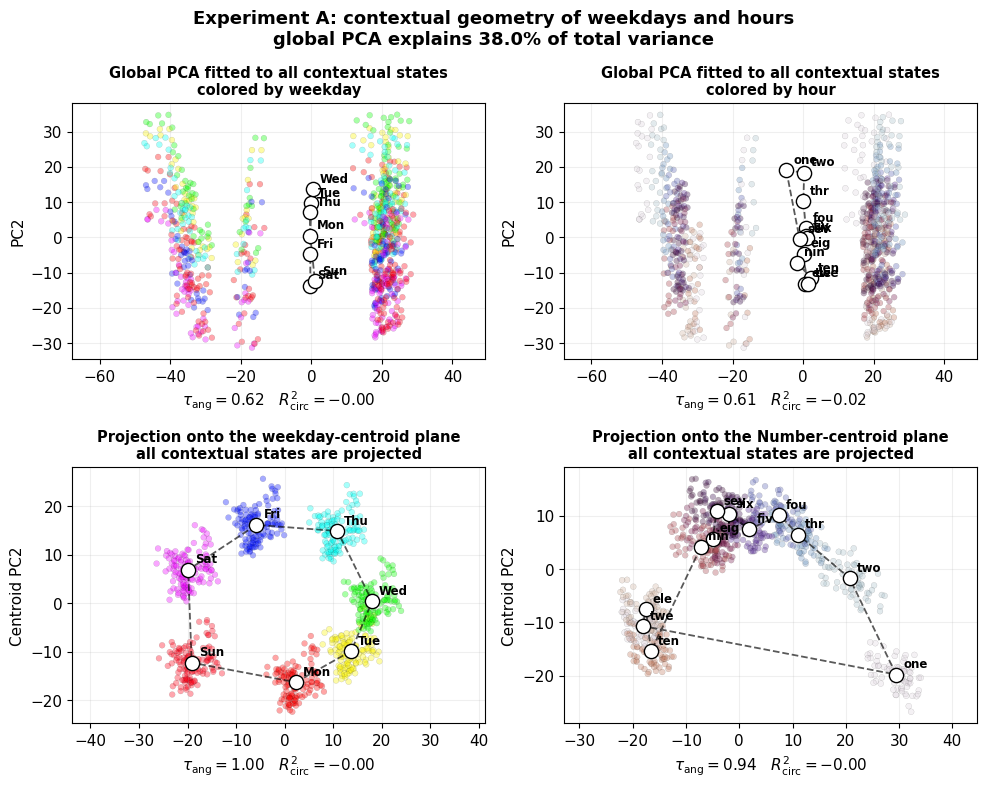

Global PCA fitted to all contextual states
  Weekdays: angular tau = 0.619, circle R² = -0.000
  Numbers:    angular tau = 0.606, circle R² = -0.020

Centroid-defined planes
  Weekdays: angular tau = 1.000, circle R² = -0.002
  Numbers:    angular tau = 0.939, circle R² = -0.002


In [15]:
#  Plot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_day_global = axes[0, 0]
ax_hour_global = axes[0, 1]
ax_day_plane = axes[1, 0]
ax_hour_plane = axes[1, 1]

#  Global PCA, colored by weekday
ax_day_global.scatter(
    H_global_2d[:, 0],
    H_global_2d[:, 1],
    c=days,
    cmap="hsv",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)
add_cycle(ax_day_global, global_day_centroids, labels=[day[:3] for day in DAYS])
ax_day_global.set_title(
    "Global PCA fitted to all contextual states\n" "colored by weekday",
    fontsize=10.5,
    fontweight="bold",
)
ax_day_global.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_global_day:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_global_day:.2f}$"
)
ax_day_global.set_ylabel("PC2")
ax_day_global.grid(alpha=0.2)
# ── Global PCA, colored by hour ──────────────────────────────────────
ax_hour_global.scatter(
    H_global_2d[:, 0],
    H_global_2d[:, 1],
    c=numbers,
    cmap="twilight",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)
add_cycle(ax_hour_global, global_hour_centroids, labels=[number[:3] for number in NUMBERS])
ax_hour_global.set_title(
    "Global PCA fitted to all contextual states\n" "colored by hour",
    fontsize=10.5,
    fontweight="bold",
)
ax_hour_global.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_global_hour:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_global_hour:.2f}$"
)
ax_hour_global.set_ylabel("PC2")
ax_hour_global.grid(alpha=0.2)
# ── Weekday-centroid plane ───────────────────────────────────────────
ax_day_plane.scatter(
    H_day_plane[:, 0],
    H_day_plane[:, 1],
    c=days,
    cmap="hsv",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)
add_cycle(ax_day_plane, day_plane_centroids, labels=[day[:3] for day in DAYS])
ax_day_plane.set_title(
    "Projection onto the weekday-centroid plane\n" "all contextual states are projected",
    fontsize=10.5,
    fontweight="bold",
)
ax_day_plane.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_day_plane:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_day_plane:.2f}$"
)
ax_day_plane.set_ylabel("Centroid PC2")
ax_day_plane.grid(alpha=0.2)
# ── Hour-centroid plane ──────────────────────────────────────────────
ax_hour_plane.scatter(
    H_hour_plane[:, 0],
    H_hour_plane[:, 1],
    c=numbers,
    cmap="twilight",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)
add_cycle(ax_hour_plane, hour_plane_centroids, labels=[number[:3] for number in NUMBERS])
ax_hour_plane.set_title(
    "Projection onto the Number-centroid plane\n" "all contextual states are projected",
    fontsize=10.5,
    fontweight="bold",
)
ax_hour_plane.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_hour_plane:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_hour_plane:.2f}$"
)
ax_hour_plane.set_ylabel("Centroid PC2")
ax_hour_plane.grid(alpha=0.2)
# Equal scaling within each panel
for ax in axes.flat:
    ax.set_aspect("equal", adjustable="datalim")
global_var = pca_global.explained_variance_ratio_.sum()
fig.suptitle(
    "Experiment A: contextual geometry of weekdays and hours\n"
    f"global PCA explains {global_var:.1%} of total variance",
    fontsize=13,
    fontweight="bold",
)
fig.tight_layout()
plt.show()
# ── Metric summary ───────────────────────────────────────────────────
print("Global PCA fitted to all contextual states")
print(f"  Weekdays: angular tau = {tau_global_day:.3f}, " f"circle R² = {r2_global_day:.3f}")
print(
    f"  Numbers:    angular tau = {tau_global_hour:.3f}, " f"circle R² = {r2_global_hour:.3f}"
)
print("\nCentroid-defined planes")
print(f"  Weekdays: angular tau = {tau_day_plane:.3f}, " f"circle R² = {r2_day_plane:.3f}")
print(f"  Numbers:    angular tau = {tau_hour_plane:.3f}, " f"circle R² = {r2_hour_plane:.3f}")

### Experiment B — day + hour, with the computation task

Same method and layer (7), but the prompts now require computing the shift (`TEMPLATES_MATH`) — the model has to add the number of days/hours to the day rather than just mention them.

In [16]:
#  Experiment B: weekday arithmetic

rows_B = []
start_day_labels_B = []
offset_labels_B = []
result_day_labels_B = []

with torch.no_grad():
    for day_idx, day in enumerate(DAYS):
        day_id = tokenizer.encode(" " + day)[0]

        for offset_idx, offset in enumerate(NUMBERS):
            offset_id = tokenizer.encode(" " + offset)[0]

            # NUMBERS contains the words one, ..., twelve.
            # The corresponding numerical offsets are 1, ..., 12.
            offset_value = offset_idx + 1
            # Ground-truth answer to the day-math prompt: the model is never told
            # this value, we compute it ourselves to later test decodability against it.
            result_day_idx = (day_idx + offset_value) % len(DAYS)

            for template in TEMPLATES_MATH:
                text = template.format(day=day, number=offset)

                token_ids = [tokenizer.eos_token_id] + tokenizer.encode(
                    text
                )  # BOS prefix — see note above

                if day_id not in token_ids or offset_id not in token_ids:
                    continue

                input_ids = torch.tensor([token_ids])

                hidden_states = model(input_ids, output_hidden_states=True).hidden_states[
                    LAYER
                ][0]

                day_state = hidden_states[token_ids.index(day_id)]
                offset_state = hidden_states[token_ids.index(offset_id)]

                rows_B.append((day_state + offset_state).cpu().numpy())

                start_day_labels_B.append(day_idx)
                offset_labels_B.append(offset_idx)
                result_day_labels_B.append(result_day_idx)


H_B = np.asarray(rows_B)

start_days_B = np.asarray(start_day_labels_B)
offsets_B = np.asarray(offset_labels_B)
result_days_B = np.asarray(result_day_labels_B)

print(
    f"H_B: {H_B.shape} "
    f"(sum of the weekday and offset hidden states, "
    f"layer {LAYER}, weekday-arithmetic context)"
)

H_B: (840, 768) (sum of the weekday and offset hidden states, layer 7, weekday-arithmetic context)


In [17]:
N_START_DAY = len(np.unique(start_days_B))
N_OFFSET = len(np.unique(offsets_B))
N_RESULT_DAY = len(np.unique(result_days_B))

start_day_acc_B = cv_accuracy(H_B, start_days_B)
offset_acc_B = cv_accuracy(H_B, offsets_B)
result_day_acc_B = cv_accuracy(H_B, result_days_B)

print(f"Start-day decoding (5-fold CV):  {start_day_acc_B:.1%}")
print(f"Offset decoding (5-fold CV):     {offset_acc_B:.1%}")
print(f"Result-day decoding (5-fold CV): {result_day_acc_B:.1%}")

Start-day decoding (5-fold CV):  97.6%
Offset decoding (5-fold CV):     99.4%
Result-day decoding (5-fold CV): 0.4%


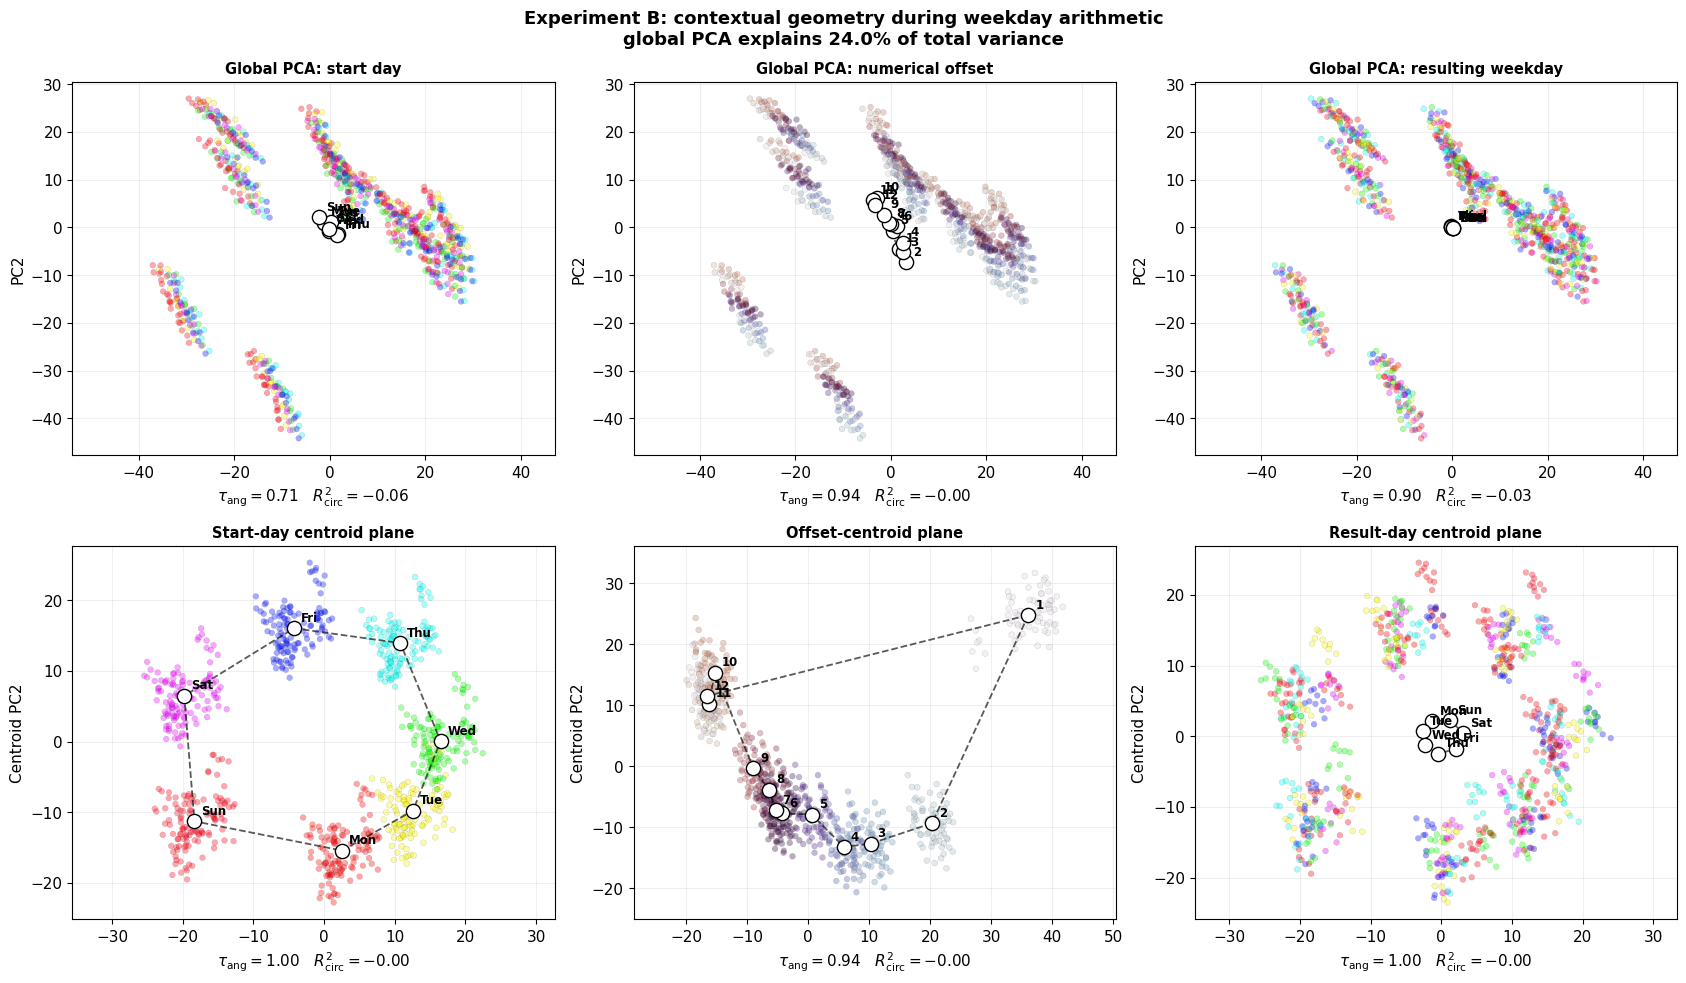

In [18]:
#  Experiment B: global PCA vs. centroid-defined planes

# add_cycle() is defined once, in the Experiment A cell above, and reused here.

#  Global PCA fitted to all contextual representations

pca_global_B = PCA(n_components=2)
H_global_B = pca_global_B.fit_transform(H_B)

global_start_centroids_B = projected_centroids(H_global_B, start_days_B, N_START_DAY)
global_offset_centroids_B = projected_centroids(H_global_B, offsets_B, N_OFFSET)
global_result_centroids_B = projected_centroids(H_global_B, result_days_B, N_RESULT_DAY)


# Metrics in the global PCA space
tau_global_start_B = angular_tau(global_start_centroids_B, N_START_DAY)
r2_global_start_B = fit_r2(global_start_centroids_B)
tau_global_offset_B = angular_tau(global_offset_centroids_B, N_OFFSET)
r2_global_offset_B = fit_r2(global_offset_centroids_B)
tau_global_result_B = angular_tau(global_result_centroids_B, N_RESULT_DAY)
r2_global_result_B = fit_r2(global_result_centroids_B)


# ── Centroid-defined planes ──────────────────────────────────────────

H_start_plane_B, B_start_B, start_center_B, pca_start_B = centroid_plane(
    H_B, start_days_B, N_START_DAY
)

H_offset_plane_B, B_offset_B, offset_center_B, pca_offset_B = centroid_plane(
    H_B, offsets_B, N_OFFSET
)

H_result_plane_B, B_result_B, result_center_B, pca_result_B = centroid_plane(
    H_B, result_days_B, N_RESULT_DAY
)


start_plane_centroids_B = projected_centroids(H_start_plane_B, start_days_B, N_START_DAY)
offset_plane_centroids_B = projected_centroids(H_offset_plane_B, offsets_B, N_OFFSET)
result_plane_centroids_B = projected_centroids(H_result_plane_B, result_days_B, N_RESULT_DAY)


# Metrics in the centroid-defined planes
tau_start_plane_B = angular_tau(start_plane_centroids_B, N_START_DAY)
r2_start_plane_B = fit_r2(start_plane_centroids_B)
tau_offset_plane_B = angular_tau(offset_plane_centroids_B, N_OFFSET)
r2_offset_plane_B = fit_r2(offset_plane_centroids_B)
tau_result_plane_B = angular_tau(result_plane_centroids_B, N_RESULT_DAY)
r2_result_plane_B = fit_r2(result_plane_centroids_B)


#  Plot

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

day_labels = [day[:3] for day in DAYS]
offset_text_labels = [str(i) for i in range(1, N_OFFSET + 1)]


#  Global PCA: start day

ax = axes[0, 0]

ax.scatter(
    H_global_B[:, 0],
    H_global_B[:, 1],
    c=start_days_B,
    cmap="hsv",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)

add_cycle(ax, global_start_centroids_B, day_labels)

ax.set_title("Global PCA: start day", fontsize=10.5, fontweight="bold")

ax.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_global_start_B:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_global_start_B:.2f}$"
)

ax.set_ylabel("PC2")
ax.grid(alpha=0.2)


#  Global PCA: offset

ax = axes[0, 1]

ax.scatter(
    H_global_B[:, 0],
    H_global_B[:, 1],
    c=offsets_B,
    cmap="twilight",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)

add_cycle(ax, global_offset_centroids_B, offset_text_labels)

ax.set_title("Global PCA: numerical offset", fontsize=10.5, fontweight="bold")

ax.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_global_offset_B:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_global_offset_B:.2f}$"
)

ax.set_ylabel("PC2")
ax.grid(alpha=0.2)


#  Global PCA: result day

ax = axes[0, 2]

ax.scatter(
    H_global_B[:, 0],
    H_global_B[:, 1],
    c=result_days_B,
    cmap="hsv",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)

add_cycle(ax, global_result_centroids_B, day_labels)

ax.set_title("Global PCA: resulting weekday", fontsize=10.5, fontweight="bold")

ax.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_global_result_B:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_global_result_B:.2f}$"
)

ax.set_ylabel("PC2")
ax.grid(alpha=0.2)


#  Start-day centroid plane

ax = axes[1, 0]

ax.scatter(
    H_start_plane_B[:, 0],
    H_start_plane_B[:, 1],
    c=start_days_B,
    cmap="hsv",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)

add_cycle(ax, start_plane_centroids_B, day_labels)

ax.set_title("Start-day centroid plane", fontsize=10.5, fontweight="bold")

ax.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_start_plane_B:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_start_plane_B:.2f}$"
)

ax.set_ylabel("Centroid PC2")
ax.grid(alpha=0.2)


#  Offset-centroid plane

ax = axes[1, 1]

ax.scatter(
    H_offset_plane_B[:, 0],
    H_offset_plane_B[:, 1],
    c=offsets_B,
    cmap="twilight",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)

add_cycle(ax, offset_plane_centroids_B, offset_text_labels)

ax.set_title("Offset-centroid plane", fontsize=10.5, fontweight="bold")

ax.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_offset_plane_B:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_offset_plane_B:.2f}$"
)

ax.set_ylabel("Centroid PC2")
ax.grid(alpha=0.2)


#  Result-day centroid plane

ax = axes[1, 2]

ax.scatter(
    H_result_plane_B[:, 0],
    H_result_plane_B[:, 1],
    c=result_days_B,
    cmap="hsv",
    s=18,
    alpha=0.35,
    edgecolor="black",
    linewidth=0.15,
)

add_cycle(ax, result_plane_centroids_B, day_labels)

ax.set_title("Result-day centroid plane", fontsize=10.5, fontweight="bold")

ax.set_xlabel(
    rf"$\tau_{{\mathrm{{ang}}}}={tau_result_plane_B:.2f}$   "
    rf"$R^2_{{\mathrm{{circ}}}}={r2_result_plane_B:.2f}$"
)

ax.set_ylabel("Centroid PC2")
ax.grid(alpha=0.2)


for ax in axes.flat:
    ax.set_aspect("equal", adjustable="datalim")


global_var_B = pca_global_B.explained_variance_ratio_.sum()

fig.suptitle(
    "Experiment B: contextual geometry during weekday arithmetic\n"
    f"global PCA explains {global_var_B:.1%} of total variance",
    fontsize=13,
    fontweight="bold",
)

fig.tight_layout()
plt.show()

In [19]:
#  Metric summary

# chance level: probability of guessing the variable correctly with no information at all

chance = {
    "Start day": 1 / N_START_DAY,
    "Offset": 1 / N_OFFSET,
    "Result day": 1 / N_RESULT_DAY,
}

summary = pd.DataFrame(
    {
        "Representation": [
            "Global PCA",
            "Global PCA",
            "Global PCA",
            "Centroid plane",
            "Centroid plane",
            "Centroid plane",
        ],
        "Variable": [
            "Start day",
            "Offset",
            "Result day",
            "Start day",
            "Offset",
            "Result day",
        ],
        "Angular τ": [
            tau_global_start_B,
            tau_global_offset_B,
            tau_global_result_B,
            tau_start_plane_B,
            tau_offset_plane_B,
            tau_result_plane_B,
        ],
        "Circle R²": [
            r2_global_start_B,
            r2_global_offset_B,
            r2_global_result_B,
            r2_start_plane_B,
            r2_offset_plane_B,
            r2_result_plane_B,
        ],
    }
)

decodability = {
    "Start day": start_day_acc_B,
    "Offset": offset_acc_B,
    "Result day": result_day_acc_B,
}

summary["Decodability"] = summary["Variable"].map(decodability)
summary["Chance level"] = summary["Variable"].map(chance)
summary = summary.round(3)

print("\nExperiment B: geometric metrics\n")
print(summary.to_string(index=False))

print("\nExperiment A: geometric metrics\n")
print(summary_A.to_string(index=False))


Experiment B: geometric metrics

Representation   Variable  Angular τ  Circle R²  Decodability  Chance level
    Global PCA  Start day      0.714     -0.057         0.976         0.143
    Global PCA     Offset      0.939     -0.001         0.994         0.083
    Global PCA Result day      0.905     -0.027         0.004         0.143
Centroid plane  Start day      1.000     -0.001         0.976         0.143
Centroid plane     Offset      0.939     -0.000         0.994         0.083
Centroid plane Result day      1.000     -0.001         0.004         0.143

Experiment A: geometric metrics

Representation Variable  Angular τ  Circle R²  Decodability  Chance level
    Global PCA      Day      0.619     -0.000         0.977         0.143
    Global PCA   Number      0.606     -0.020         0.998         0.083
Centroid plane      Day      1.000     -0.002         0.977         0.143
Centroid plane   Number      0.939     -0.002         0.998         0.083


### Making sense of the pretty pictures and the metrics

So, here's what we computed:

- Angular τ — a cyclicity metric
- Circle R² — a roundness metric
- Decodability — a metric of how linearly separable the day/number is from everything else
- Chance level — a guessing-baseline metric

What we see:

- **Circle R² — near zero everywhere.** In none of the conditions (A/B, Global PCA/centroid plane) is the geometry round.

- **Angular τ** on the centroid plane is near-perfect for almost every variable, and, overall, a bit better for the day-math task.

- Decodability — this is the CV accuracy of a logistic regression trained to predict the variable from the hidden state (5 folds, honestly held out) — how linearly readable the variable is "from the outside," rather than just participating somewhere in the model's computation — corrects our conclusions here. As we can see:

  - Start day: **97.9%** (chance 14.3%) — decodable, and the order ($\tau=1.000$) reflects real structure.
  - Offset: **99.1%** (chance 8.3%) — same story.
  - Result day: **0.4%** (chance 14.3%, i.e. *below* chance) — at this token position, the model
    hasn't computed the answer yet. And yet $\tau=1.000$ (centroid plane), and even $0.905$ on the raw
    Global PCA — higher than Start day's ($\tau=0.619$ on Global PCA)! So, judging by the angular metric
    alone, noise (Result day) looks "more structured" than the real, decodable
    structure (Start day). With few classes, random, near-coincident centroids easily
    line up into a plausible-looking order — and we can see this collapse directly on the PCA plot.

That's the non-trivial structure we ended up with. There's a reason for it too [footnote 2].

- Papers that show $S^1$ in models tend to use layer-wise SAE latents, for one thing.
- GPT-2, as a model, just isn't good at day-math. On a similar task, the paper's authors report 8/49 (16.3%) on Weekdays and 10/144 (6.9%) on Months — against a chance level of $1/7\approx14.3\%$ and $1/12\approx8.3\%$. In other words, the model isn't computing during generation — it's guessing.

A quote from the paper: "although GPT-2 has circular representations, it gets trivial accuracy on Weekdays and Months"

My own quote: what a clueless little thing!

All in all, what we got in our experiment — our result — is exactly the picture you'd expect from a model like this one.

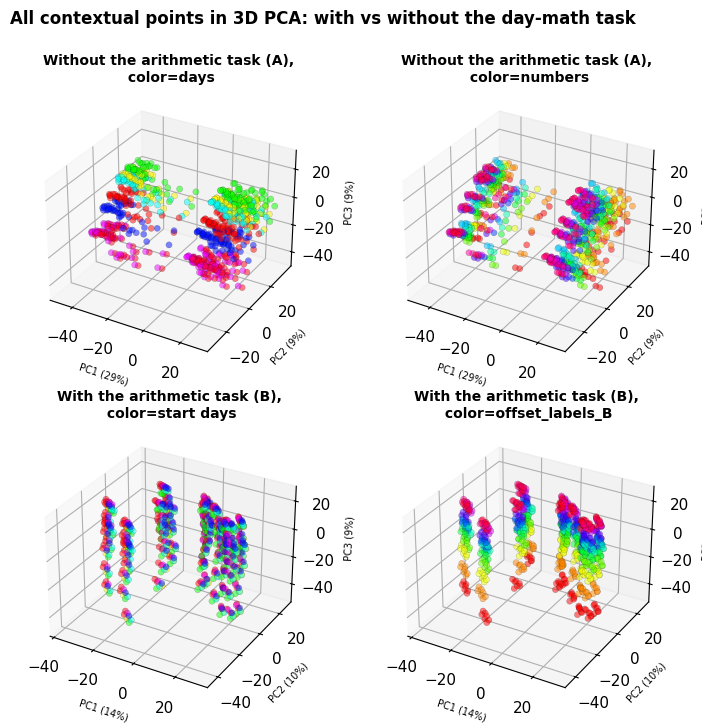

In [20]:
# ── 3D PCA: all contextual points, without vs with the arithmetic task ──
def pca3_points(X):
    pca = PCA(n_components=3).fit(X - X.mean(0))
    return pca.transform(X - X.mean(0)), pca.explained_variance_ratio_


# Two colorings per experiment: if day and number were both cleanly
# represented, we would expect the two colorings to reveal different,
# consistent groupings of the same point cloud.
pts_A, ev_A = pca3_points(H)
pts_B, ev_B = pca3_points(H_B)

fig, axes = plt.subplots(2, 2, figsize=(20, 8), subplot_kw={"projection": "3d"})
axes = axes.flatten()

for i, (pts, ev, labels, title) in enumerate(
    [
        (pts_A, ev_A, days, "Without the arithmetic task (A),\n color=days"),
        (pts_A, ev_A, numbers, "Without the arithmetic task (A),\n color=numbers"),
        (pts_B, ev_B, start_days_B, "With the arithmetic task (B),\n color=start days"),
        (
            pts_B,
            ev_B,
            offset_labels_B,
            "With the arithmetic task (B),\n color=offset_labels_B",
        ),
    ]
):
    axes[i].scatter(
        pts[:, 0],
        pts[:, 1],
        pts[:, 2],
        c=labels,
        cmap="hsv",
        # s=18,
        alpha=0.5,
        edgecolor="black",
        linewidth=0.15,
    )
    axes[i].set_xlabel(
        f"PC1 ({ev[0]:.0%})",
        fontsize=7,
    )
    axes[i].set_ylabel(
        f"PC2 ({ev[1]:.0%})",
        fontsize=7,
    )
    axes[i].set_zlabel(f"PC3 ({ev[2]:.0%})", fontsize=7)
    axes[i].set_title(title, fontsize=10, fontweight="bold")

fig.suptitle(
    "All contextual points in 3D PCA: with vs without the day-math task",
    fontsize=12,
    fontweight="bold",
)
fig.subplots_adjust(wspace=-0.7)
plt.show()

## Wrapping up — the takeaways to keep

We've come a long way together — from the theorem to reality — and seen that there is no clean theory that applies directly to model embeddings. You've been introduced to Whitney's theorem and the notion of manifolds, and you've seen the following results:

- **Whitney's theorem is only a theoretical hint about the size of possible structures and how to go looking for them.** In reality, things in models are more complicated — polysemanticity doesn't limit how many manifolds can be packed in, and extracting manifolds in their pure form requires scale in the data.

- **GPT-2's token embeddings ($W_E$) are cyclic.** Days and months give a perfect cyclic order ($\tau=1.0$), numbers give an
  almost-perfect one ($\tau=0.94$). But the geometry isn't round for any of the three ($R^2_{\text{circ}}$ ranging from $-0.005$ to $-0.024$): the model stores **order**, not a circle.

- **Context makes the problem harder, but it doesn't break what we found in the simpler approximation.** Across layers 0–11 the order stays perfect ($\tau=1.0$); at the last, 12th layer, it dips a bit ($\tau=0.81$).

- **Interpretability, as a process, comes with its own methodological gotchas.** The third variable in B — the **result** of the addition — is decodable at only 0.4%, below random guessing (14.3%). And yet the formal circularity metric for "result" shows $\tau$ as high as 0.9 — that's an artifact of near-coincident centroids, not structure. This is exactly the class of mistake worth watching out for in tests like these: **a high angular metric says nothing about structure if separability — if the control metric — sits at chance level.**

Look how much ground we covered! Well done, you! Thanks for reading all the way to the end!

Footnote: [1] This experiment can be extended to more cyclic pairs, and to bigger models (Mistral/Llama, where, per the literature, the circles come out cleaner).

I hope the tutorial was engaging for you, and that you got to feel some of the beauty and ambiguity of hunting for structure in models.

Until next time, friends!

If you enjoyed this, as always, I invite you to:
- [Telegram Blog, ru](https://t.me/jdata_blog)
- [Substack, en](https://substack.com/@sabrinasadiekh)
- [Medium, en](https://medium.com/@sadsobr7)
- [LinkedIn](www.linkedin.com/in/sabrina-sadiekh)